In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("students.csv")

In [3]:
df

,Name,Marks,City
0,A,85,Delhi
1,B,78,Mumbai
2,C,92,Delhi
3,D,70,Chennai
4,E,88,Mumbai
5,F,95,Delhi
6,G,60,Chennai
7,H,82,Mumbai
8,I,76,Delhi
9,J,89,Chennai


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Name    10 non-null     object
 1   Marks   10 non-null     int64 
 2   City    10 non-null     object
dtypes: int64(1), object(2)
memory usage: 372.0+ bytes


In [5]:
df.isnull().sum()

Name     0
Marks    0
City     0
dtype: int64

In [6]:
df["Marks"] = df["Marks"].astype(float)

In [7]:
df

,Name,Marks,City
0,A,85.0,Delhi
1,B,78.0,Mumbai
2,C,92.0,Delhi
3,D,70.0,Chennai
4,E,88.0,Mumbai
5,F,95.0,Delhi
6,G,60.0,Chennai
7,H,82.0,Mumbai
8,I,76.0,Delhi
9,J,89.0,Chennai


In [8]:
df["Status"] = df["Marks"].apply(lambda x: "Pass" if x >= 75 else "Fail")

In [9]:
df

,Name,Marks,City,Status
0,A,85.0,Delhi,Pass
1,B,78.0,Mumbai,Pass
2,C,92.0,Delhi,Pass
3,D,70.0,Chennai,Fail
4,E,88.0,Mumbai,Pass
5,F,95.0,Delhi,Pass
6,G,60.0,Chennai,Fail
7,H,82.0,Mumbai,Pass
8,I,76.0,Delhi,Pass
9,J,89.0,Chennai,Pass


In [10]:
df["Grade"] = df["Marks"].apply(lambda x: "A" if x >90 else ("B" if x > 80 else "C"))

In [11]:
df

,Name,Marks,City,Status,Grade
0,A,85.0,Delhi,Pass,B
1,B,78.0,Mumbai,Pass,C
2,C,92.0,Delhi,Pass,A
3,D,70.0,Chennai,Fail,C
4,E,88.0,Mumbai,Pass,B
5,F,95.0,Delhi,Pass,A
6,G,60.0,Chennai,Fail,C
7,H,82.0,Mumbai,Pass,B
8,I,76.0,Delhi,Pass,C
9,J,89.0,Chennai,Pass,B


In [12]:
df.groupby("City")["Marks"].mean()

City
Chennai    73.000000
Delhi      87.000000
Mumbai     82.666667
Name: Marks, dtype: float64

In [13]:
df.nlargest(1,"Marks")

,Name,Marks,City,Status,Grade
5,F,95.0,Delhi,Pass,A


In [14]:
df.nsmallest(3,"Marks")

,Name,Marks,City,Status,Grade
6,G,60.0,Chennai,Fail,C
3,D,70.0,Chennai,Fail,C
8,I,76.0,Delhi,Pass,C


In [15]:
df[(df["Marks"] > 80) & (df["City"] == "Delhi")]

,Name,Marks,City,Status,Grade
0,A,85.0,Delhi,Pass,B
2,C,92.0,Delhi,Pass,A
5,F,95.0,Delhi,Pass,A


In [16]:
df["Status"].value_counts()

Status
Pass    8
Fail    2
Name: count, dtype: int64

In [17]:
df.sort_values(by="Marks",ascending=False)

,Name,Marks,City,Status,Grade
5,F,95.0,Delhi,Pass,A
2,C,92.0,Delhi,Pass,A
9,J,89.0,Chennai,Pass,B
4,E,88.0,Mumbai,Pass,B
0,A,85.0,Delhi,Pass,B
7,H,82.0,Mumbai,Pass,B
1,B,78.0,Mumbai,Pass,C
8,I,76.0,Delhi,Pass,C
3,D,70.0,Chennai,Fail,C
6,G,60.0,Chennai,Fail,C


In [18]:
df["Performance"] = df["Marks"].apply(lambda x: "High" if x > 85 else "Low")

In [19]:
df

,Name,Marks,City,Status,Grade,Performance
0,A,85.0,Delhi,Pass,B,Low
1,B,78.0,Mumbai,Pass,C,Low
2,C,92.0,Delhi,Pass,A,High
3,D,70.0,Chennai,Fail,C,Low
4,E,88.0,Mumbai,Pass,B,High
5,F,95.0,Delhi,Pass,A,High
6,G,60.0,Chennai,Fail,C,Low
7,H,82.0,Mumbai,Pass,B,Low
8,I,76.0,Delhi,Pass,C,Low
9,J,89.0,Chennai,Pass,B,High


In [20]:
df.groupby("City") ["Status"].value_counts()

City     Status
Chennai  Fail      2
         Pass      1
Delhi    Pass      4
Mumbai   Pass      3
Name: count, dtype: int64

In [21]:
df["Grade"].value_counts()

Grade
B    4
C    4
A    2
Name: count, dtype: int64

In [22]:
df.groupby("City")["Marks"].max()

City
Chennai    89.0
Delhi      95.0
Mumbai     88.0
Name: Marks, dtype: float64

In [23]:
df.loc[df.groupby("City")["Marks"].idxmax()]

,Name,Marks,City,Status,Grade,Performance
9,J,89.0,Chennai,Pass,B,High
5,F,95.0,Delhi,Pass,A,High
4,E,88.0,Mumbai,Pass,B,High


In [24]:
df["Distinction"] = df["Marks"].apply(lambda x: "Yes" if x >=85 else "No")

In [25]:
df

,Name,Marks,City,Status,Grade,Performance,Distinction
0,A,85.0,Delhi,Pass,B,Low,Yes
1,B,78.0,Mumbai,Pass,C,Low,No
2,C,92.0,Delhi,Pass,A,High,Yes
3,D,70.0,Chennai,Fail,C,Low,No
4,E,88.0,Mumbai,Pass,B,High,Yes
5,F,95.0,Delhi,Pass,A,High,Yes
6,G,60.0,Chennai,Fail,C,Low,No
7,H,82.0,Mumbai,Pass,B,Low,No
8,I,76.0,Delhi,Pass,C,Low,No
9,J,89.0,Chennai,Pass,B,High,Yes


In [26]:
avg = df["Marks"].mean()
df[df["Marks"] > avg]

,Name,Marks,City,Status,Grade,Performance,Distinction
0,A,85.0,Delhi,Pass,B,Low,Yes
2,C,92.0,Delhi,Pass,A,High,Yes
4,E,88.0,Mumbai,Pass,B,High,Yes
5,F,95.0,Delhi,Pass,A,High,Yes
7,H,82.0,Mumbai,Pass,B,Low,No
9,J,89.0,Chennai,Pass,B,High,Yes


**Project Insights**
1. Delhi has highest average marks(87)
2. Top score is F with 95 marks
3. 8 students passed and 2 failed
4. Chennai has lower average performance
5. High performers mostly belong to Delhi
   

In [27]:
[df.groupby("Name")["Marks"].max() ]

[Name
 A    85.0
 B    78.0
 C    92.0
 D    70.0
 E    88.0
 F    95.0
 G    60.0
 H    82.0
 I    76.0
 J    89.0
 Name: Marks, dtype: float64]

In [28]:
df[df["Marks"] > 90]

,Name,Marks,City,Status,Grade,Performance,Distinction
2,C,92.0,Delhi,Pass,A,High,Yes
5,F,95.0,Delhi,Pass,A,High,Yes


In [29]:
df["Scholarship"] = df["Marks"].apply(lambda x: "Yes" if x >= 90 else "No")

In [30]:
df

,Name,Marks,City,Status,Grade,Performance,Distinction,Scholarship
0,A,85.0,Delhi,Pass,B,Low,Yes,No
1,B,78.0,Mumbai,Pass,C,Low,No,No
2,C,92.0,Delhi,Pass,A,High,Yes,Yes
3,D,70.0,Chennai,Fail,C,Low,No,No
4,E,88.0,Mumbai,Pass,B,High,Yes,No
5,F,95.0,Delhi,Pass,A,High,Yes,Yes
6,G,60.0,Chennai,Fail,C,Low,No,No
7,H,82.0,Mumbai,Pass,B,Low,No,No
8,I,76.0,Delhi,Pass,C,Low,No,No
9,J,89.0,Chennai,Pass,B,High,Yes,No


In [31]:
df.groupby("City")["Marks"].mean()

City
Chennai    73.000000
Delhi      87.000000
Mumbai     82.666667
Name: Marks, dtype: float64

In [32]:
avg = df["Marks"].mean()
df[df["Marks"] > avg]

,Name,Marks,City,Status,Grade,Performance,Distinction,Scholarship
0,A,85.0,Delhi,Pass,B,Low,Yes,No
2,C,92.0,Delhi,Pass,A,High,Yes,Yes
4,E,88.0,Mumbai,Pass,B,High,Yes,No
5,F,95.0,Delhi,Pass,A,High,Yes,Yes
7,H,82.0,Mumbai,Pass,B,Low,No,No
9,J,89.0,Chennai,Pass,B,High,Yes,No


In [33]:
df["Topper"] = df["Marks"].apply(lambda x : "Yes" if x >= 90 else "No")

In [34]:
df

,Name,Marks,City,Status,Grade,Performance,Distinction,Scholarship,Topper
0,A,85.0,Delhi,Pass,B,Low,Yes,No,No
1,B,78.0,Mumbai,Pass,C,Low,No,No,No
2,C,92.0,Delhi,Pass,A,High,Yes,Yes,Yes
3,D,70.0,Chennai,Fail,C,Low,No,No,No
4,E,88.0,Mumbai,Pass,B,High,Yes,No,No
5,F,95.0,Delhi,Pass,A,High,Yes,Yes,Yes
6,G,60.0,Chennai,Fail,C,Low,No,No,No
7,H,82.0,Mumbai,Pass,B,Low,No,No,No
8,I,76.0,Delhi,Pass,C,Low,No,No,No
9,J,89.0,Chennai,Pass,B,High,Yes,No,No


In [35]:
df.groupby(["City","Grade"]).size().unstack(fill_value=0)

Grade,A,B,C
City,,,
Chennai,0,1,2
Delhi,2,1,1
Mumbai,0,2,1


In [38]:
df.groupby("City")["Marks"].agg(["mean","max","min","count"])

,mean,max,min,count
City,,,,
Chennai,73.000000,89.0,60.0,3
Delhi,87.000000,95.0,76.0,4
Mumbai,82.666667,88.0,78.0,3


In [48]:
df.groupby("City").agg(
    Avg_marks=("Marks","mean"),
    Top_score=("Marks","max")
)


,Avg_marks,Top_score
City,,
Chennai,73.000000,89.0
Delhi,87.000000,95.0
Mumbai,82.666667,88.0


In [49]:
students = pd.DataFrame({
    "id":[1,2,3],
    "name":["A","B","C"]
})

In [50]:
students

,id,name
0,1,A
1,2,B
2,3,C


In [51]:
marks = pd.DataFrame({
    "id":[1,2,3],
    "marks":[85,90,78]
})

In [52]:
marks

,id,marks
0,1,85
1,2,90
2,3,78


In [53]:
pd.merge(students,marks,on="id")

,id,name,marks
0,1,A,85
1,2,B,90
2,3,C,78


In [54]:
pd.pivot_table(
    df,
    values="Marks",
    index = "City",
    aggfunc = "mean"
)

,Marks
City,
Chennai,73.000000
Delhi,87.000000
Mumbai,82.666667


<Axes: xlabel='City'>

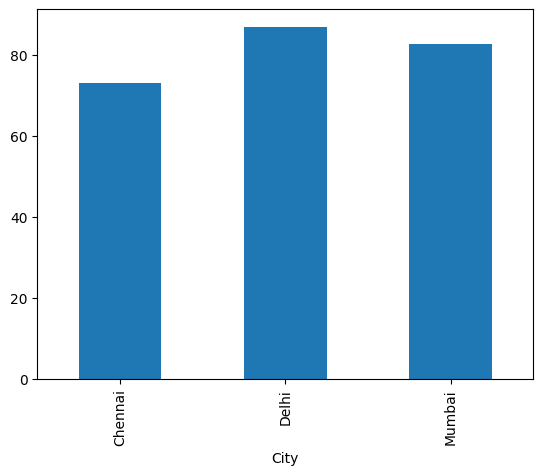

In [59]:
avg = df.groupby("City")["Marks"].mean()
avg.plot(kind="bar")